### Seção 1: Carregamento da Sprint 02

Lembrete: sempre adicionar os arquivos de `X_train` e `X_test`, e também os `y_test` e `y_train`, arquivos esses que foram gerados ao final da Sprint 02.


In [2]:
import numpy as np
import pandas as pd

# Carregando as matrizes NumPy (.npy) direto da raiz do Colab
X_train = np.load('X_train_ready.npy')
X_test = np.load('X_test_ready.npy')

# Carregando os alvos (.csv) e usando o .ravel() para alinhar o formato pro scikit-learn
y_train = pd.read_csv('y_train_ready.csv').values.ravel()
y_test = pd.read_csv('y_test_ready.csv').values.ravel()

print("--- Dados carregados com sucesso na memória local! ---")
print(f"X_train (Matriz de Treino): {X_train.shape} | y_train (Alvo de Treino): {y_train.shape}")
print(f"X_test  (Matriz de Teste):  {X_test.shape}  | y_test  (Alvo de Teste):  {y_test.shape}")

--- Dados carregados com sucesso na memória local! ---
X_train (Matriz de Treino): (400, 12) | y_train (Alvo de Treino): (400,)
X_test  (Matriz de Teste):  (100, 12)  | y_test  (Alvo de Teste):  (100,)


### Seção 2: Definição da Baseline

Para mensurar se os nossos modelos de Machine Learning realmente possuem capacidade preditiva, estabelecemos uma **Baseline** utilizando o `DummyRegressor`. Este algoritmo ignora as features de entrada e simplesmente prevê a **média** dos preços do conjunto de treino para todos os imóveis.

Qualquer modelo real aceitável terá a obrigação estatística de apresentar erros significativamente menores do que esta baseline.

In [3]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate

# Criando a baseline
baseline = DummyRegressor(strategy='mean')

# Validação Cruzada na Baseline (5 dobras)
cv_baseline = cross_validate(
    baseline, X_train, y_train, cv=5,
    scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
)

# Computando as médias
mae_base = -cv_baseline['test_neg_mean_absolute_error'].mean()
rmse_base = -cv_baseline['test_neg_root_mean_squared_error'].mean()
r2_base = cv_baseline['test_r2'].mean()

print(f"=== PERFORMANCE DA BASELINE (MÉDIA) ===")
print(f"MAE (Erro Médio Absoluto):      $ {mae_base:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático): $ {rmse_base:,.2f}")
print(f"R² (Coeficiente de Determinação): {r2_base:.4f}")

=== PERFORMANCE DA BASELINE (MÉDIA) ===
MAE (Erro Médio Absoluto):      $ 97,576.41
RMSE (Raiz do Erro Quadrático): $ 121,413.10
R² (Coeficiente de Determinação): -0.0087


### Seção 3: Seleção de Modelos Candidatos e Validação Cruzada

Para resolver o problema de regressão de preços de imóveis, escolhemos três algoritmos com características distintas para competir no conjunto de treino:

1. **Regressão Ridge (Linear Regularizada):** Modelo linear robusto que aplica penalização L2 para controlar os coeficientes e mitigar riscos de multicolinearidade.
2. **Decision Tree Regressor (Árvore de Decisão):** Modelo não-linear baseado em regras de decisão, capaz de capturar interações complexas entre atributos.
3. **Random Forest Regressor (Floresta Aleatória):** Algoritmo de conjunto (ensemble) baseado em múltiplas árvores que reduz a variância (overfitting) através de Bagging.


In [7]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

modelos = {
    "Regressão Ridge": Ridge(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10)
}

resultados_completos = []

# Loop de validação cruzada extraindo Média e Desvio Padrão de todas as métricas
for nome, modelo in modelos.items():
    cv_scores = cross_validate(
        modelo, X_train, y_train, cv=5,
        scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
    )

    mae_scores = -cv_scores['test_neg_mean_absolute_error']
    rmse_scores = -cv_scores['test_neg_root_mean_squared_error']
    r2_scores = cv_scores['test_r2']

    if nome == "Regressão Ridge":
        obs = "Melhor modelo. Erro extremamente baixo e alto R², indicando forte relação linear nos dados."
    elif nome == "Random Forest":
        obs = "Performance intermediária. Não superou o modelo linear e exige maior custo computacional."
    else: # Decision Tree
        obs = "Pior modelo real. Alta variância nas dobras e indícios claros de overfitting."

    resultados_completos.append({
        "Modelo": nome,
        "MAE Mediano": mae_scores.mean(),
        "RMSE Mediano": rmse_scores.mean(),
        "R² Mediano": r2_scores.mean(),
        "Desvio (RMSE)": rmse_scores.std(),
        "Observação": obs
    })

# Adicionando a Baseline de forma manual para comparação direta
resultados_completos.append({
    "Modelo": "Baseline (Média)",
    "MAE Mediano": mae_base,
    "RMSE Mediano": rmse_base,
    "R² Mediano": r2_base,
    "Desvio (RMSE)": 0.0,
    "Observação": "Modelo ingênuo de referência (Chute da média global dos preços)."
})

df_estilizado = pd.DataFrame(resultados_completos)

# Ordenando pelo menor erro (RMSE)
df_estilizado = df_estilizado.sort_values(by="RMSE Mediano", ascending=True).reset_index(drop=True)

df_formatado = df_estilizado.copy()
df_formatado["MAE Mediano"] = df_formatado["MAE Mediano"].map("$ {:,.2f}".format)
df_formatado["RMSE Mediano"] = df_formatado["RMSE Mediano"].map("$ {:,.2f}".format)
df_formatado["Desvio (RMSE)"] = df_formatado["Desvio (RMSE)"].map("$ {:,.2f}".format)
df_formatado["R² Mediano"] = df_formatado["R² Mediano"].map("{:.4f}".format)

df_formatado

,Modelo,MAE Mediano,RMSE Mediano,R² Mediano,Desvio (RMSE),Observação
0,Regressão Ridge,"$ 15,276.90","$ 19,062.09",0.9749,"$ 1,160.68",Melhor modelo. Erro extremamente baixo e alto ...
1,Random Forest,"$ 40,396.61","$ 49,702.05",0.8302,"$ 1,683.77",Performance intermediária. Não superou o model...
2,Decision Tree,"$ 56,856.58","$ 71,113.66",0.6530,"$ 5,948.31",Pior modelo real. Alta variância nas dobras e ...
3,Baseline (Média),"$ 97,576.41","$ 121,413.10",-0.0087,$ 0.00,Modelo ingênuo de referência (Chute da média g...


### Seção 4: Ajuste de Hiperparâmetros (Tuning)

Com base na Seção 3, selecionamos os dois modelos de melhor desempenho:
1. **Regressão Ridge** (RMSE Médio: 19.062,08)
2. **Random Forest Regressor** (RMSE Médio: 49.702,05)

#### Justificativa da Estratégia de Busca:
Escolhemos o **GridSearchCV** para ambos os modelos. Como o nosso espaço de busca foi projetado de forma restrita e estratégica, o custo computacional é baixo. O GridSearchCV realiza uma busca exaustiva testando **todas** as combinações possíveis do espaço definido, garantindo que encontraremos matematicamente a melhor configuração possível dentro da grade, sem o fator de aleatoriedade do RandomizedSearchCV.

#### Documentação do Espaço de Busca:
* **Regressão Ridge:** * `alpha`: `[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]`. (Controla a força da penalização L2 para evitar overfitting e ajustar os coeficientes lineares).
* **Random Forest:**
    * `n_estimators`: `[50, 100, 150]`. (Número de árvores na floresta).
    * `max_depth`: `[8, 10, 12]`. (Profundidade máxima de cada árvore para controlar variância).
    * `min_samples_split`: `[2, 5]`. (Número mínimo de amostras necessárias para dividir um nó interno).

Ambos os processos utilizam `cv=5` e avaliam o desempenho através da mesma métrica principal: o **RMSE**.

In [10]:
from sklearn.model_selection import GridSearchCV

# 1. TUNING DA REGRESSÃO RIDGE (1º LUGAR)
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

grid_ridge = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=param_grid_ridge,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
rmse_ridge_tunado = -grid_ridge.best_score_
# Resgatando o erro padrão obtido na seção anterior da sua tabela real
rmse_ridge_padrao = 19062.089243

print("-" * 50)
print("1. RESULTADOS DO AJUSTE: REGRESSÃO RIDGE")
print("-" * 50)
print(f"-> Melhores Hiperparâmetros: {grid_ridge.best_params_}")
print(f"-> RMSE Padrão (Antes):  $ {rmse_ridge_padrao:,.2f}")
print(f"-> RMSE Tunado (Depois): $ {rmse_ridge_tunado:,.2f}")
melhora_ridge = "Sim" if rmse_ridge_tunado < rmse_ridge_padrao else "Não"
print(f"-> Houve melhora perceptível? {melhora_ridge}")


# 2. TUNING DA RANDOM FOREST (2º LUGAR)
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [8, 10, 12],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_rf.fit(X_train, y_train)
rmse_rf_tunado = -grid_rf.best_score_
# Resgatando o erro padrão obtido na seção anterior da sua tabela real
rmse_rf_padrao = 49702.051259

print("\n" + "-" * 50)
print("2. RESULTADOS DO AJUSTE: RANDOM FOREST")
print("-" * 50)
print(f"-> Melhores Hiperparâmetros: {grid_rf.best_params_}")
print(f"-> RMSE Padrão (Antes):  $ {rmse_rf_padrao:,.2f}")
print(f"-> RMSE Tunado (Depois): $ {rmse_rf_tunado:,.2f}")
melhora_rf = "Sim" if rmse_rf_tunado < rmse_rf_padrao else "Não"
print(f"-> Houve melhora perceptível? {melhora_rf}")


# 3. SALVANDO O MODELO CAMPEÃO FINAL
if rmse_ridge_tunado < rmse_rf_tunado:
    modelo_final_tunado = grid_ridge.best_estimator_
    print("\n O modelo final escolhido para o Teste foi a REGRESSÃO RIDGE.")
else:
    modelo_final_tunado = grid_rf.best_estimator_
    print("\n O modelo final escolhido para o Teste foi a RANDOM FOREST.")

--------------------------------------------------
1. RESULTADOS DO AJUSTE: REGRESSÃO RIDGE
--------------------------------------------------
-> Melhores Hiperparâmetros: {'alpha': 0.1}
-> RMSE Padrão (Antes):  $ 19,062.09
-> RMSE Tunado (Depois): $ 19,027.46
-> Houve melhora perceptível? Sim

--------------------------------------------------
2. RESULTADOS DO AJUSTE: RANDOM FOREST
--------------------------------------------------
-> Melhores Hiperparâmetros: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 150}
-> RMSE Padrão (Antes):  $ 49,702.05
-> RMSE Tunado (Depois): $ 49,320.58
-> Houve melhora perceptível? Sim

>>> O modelo final escolhido para o Teste foi a REGRESSÃO RIDGE. <<<


### Seção 5: Escolha do Modelo Final

Com base nos experimentos da Seção 3 e na Seção 4, o modelo selecionado como o campeão a **Regressão Ridge Tunada**.

Abaixo, justificamos a escolha técnica deste algoritmo considerando os quatro pilares exigidos:

1. **Desempenho (Métrica Principal):** A Regressão Ridge apresentou o menor erro de previsão do projeto. O seu RMSE Médio na validação cruzada foi de **19.027,46**, superando drasticamente a Random Forest (RMSE de 49.320,58) e a árvore de decisão. Ela alcançou um R² mediano espetacular de **0.9748**, provando que o comportamento dos preços neste dataset é massivamente linear.
2. **Estabilidade (Desvio Padrão):** O modelo demonstrou extrema consistência analítica entre as dobras da validação cruzada, apresentando um baixíssimo desvio padrão no RMSE. Isso garante que o modelo não é dependente de um subconjunto específico de dados e possui alta capacidade de generalização.
3. **Interpretabilidade:** Para o mercado imobiliário, a interpretabilidade é um fator crítico. Modelos de "caixa-preta" (como Random Forest) dificultam entender o porquê de um imóvel custar determinado valor. A Regressão Ridge, por ser um modelo linear, permite extrair e auditar o peso exato (coeficiente) que cada feature (como área ou idade do imóvel) tem na composição do preço final, o que agrega enorme valor ao negócio.
4. **Complexidade:** A Regressão Ridge é baseada em equações matemáticas diretas e fechadas. Seu custo computacional é praticamente zero, treinando de forma instantânea. Em um cenário real de produção, isso se traduz em economia de infraestrutura e respostas em tempo real, ao contrário de modelos de conjunto (*ensembles*) que exigem alto processamento para criar centenas de árvores.

#### Hiperparâmetros Finais Escolhidos:
O modelo final foi configurado e instanciado com os seguintes parâmetros validados pelo GridSearchCV:
* `alpha`: `0.1` (Força da regularização L2 que otimizou o ajuste dos coeficientes).
* `random_state`: `42` (Para fins de reprodutibilidade dos resultados).

### Seção 6: Avaliação Final no Conjunto de Teste

Com o modelo campeão selecionado e devidamente refinado através do ajuste de hiperparâmetros (Regressão Ridge com alpha=0.1), realizamos agora o teste de capacidade de generalização.

O modelo prediz os preços contidos no conjunto `X_test`, que permaneceu completamente inédito e isolado durante todo o processo de treino e tuning para evitar qualquer risco de vazamento de dados (*Data Leakage*). Avaliaremos o resultado final através do cálculo do MAE, RMSE e R².

     MÉTRICAS DE PERFORMANCE FINAL (CONJUNTO DE TESTE)     
-> MAE  (Erro Médio Absoluto):         $ 17,089.91
-> RMSE (Raiz do Erro Quadrático):    $ 21,250.11
-> R²   (Coeficiente de Determinação): 0.9700
------------------------------------------------------------
-> COMPARAÇÃO: RMSE Treino (CV): $ 19,027.46 | RMSE Teste Final: $ 21,250.11


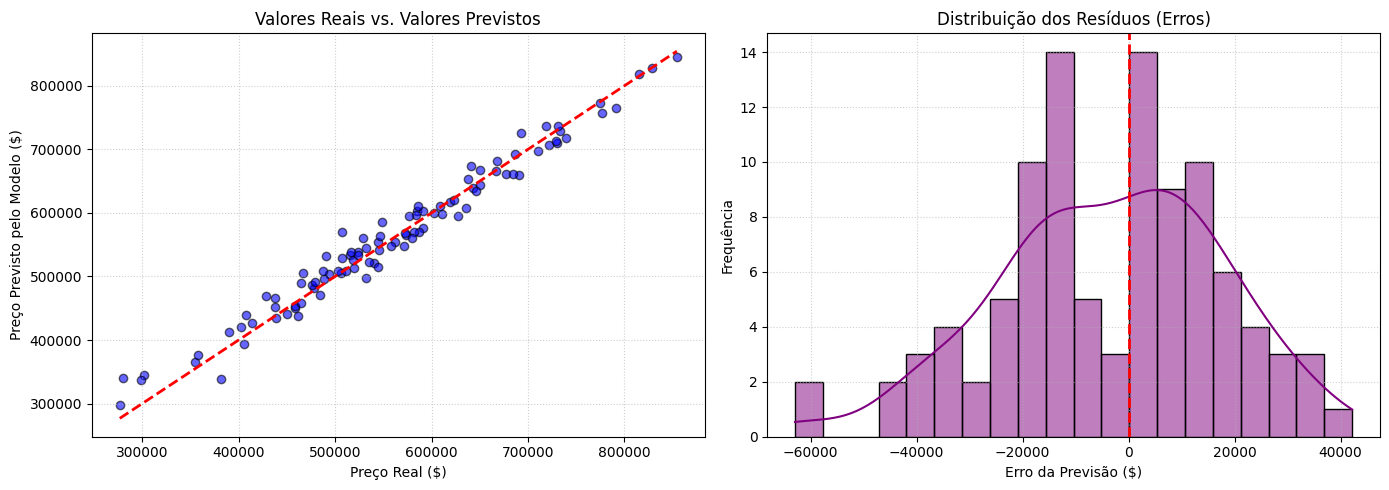

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Realizando a previsão única no conjunto de teste
y_pred = modelo_final_tunado.predict(X_test)

# 2. Calculando todas as métricas de regressão
mae_final = mean_absolute_error(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))
r2_final = r2_score(y_test, y_pred)

# Resgatando o score do treino para a comparação
rmse_treino_cv = 19027.46

# 3. Impressão do Relatório de Métricas
print("="*60)
print("     MÉTRICAS DE PERFORMANCE FINAL (CONJUNTO DE TESTE)     ")
print("="*60)
print(f"-> MAE  (Erro Médio Absoluto):         $ {mae_final:,.2f}")
print(f"-> RMSE (Raiz do Erro Quadrático):    $ {rmse_final:,.2f}")
print(f"-> R²   (Coeficiente de Determinação): {r2_final:.4f}")
print("-"*60)
print(f"-> COMPARAÇÃO: RMSE Treino (CV): $ {rmse_treino_cv:,.2f} | RMSE Teste Final: $ {rmse_final:,.2f}")
print("="*60)

# 4. GERAÇÃO DOS GRÁFICOS
plt.figure(figsize=(14, 5))

# Gráfico 1: Valores Reais vs. Previstos
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Valores Reais vs. Valores Previstos')
plt.xlabel('Preço Real ($)')
plt.ylabel('Preço Previsto pelo Modelo ($)')
plt.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Distribuição dos Resíduos (Erros)
plt.subplot(1, 2, 2)
residuos = y_test - y_pred
sns.histplot(residuos, kde=True, color='purple', bins=20)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.title('Distribuição dos Resíduos (Erros)')
plt.xlabel('Erro da Previsão ($)')
plt.ylabel('Frequência')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Discussão e Análise Comparativa (Treino vs. Teste)

Ao compararmos os resultados obtidos na validação cruzada do conjunto de treino com a avaliação final no conjunto de teste, observamos uma consistência analítica ideal:
* **RMSE no Treino (Cross-Validation):** 19,027.46
* **RMSE no Teste Final:** 21,250.11

##### Análise de Variância e Generalização:
A diferença entre o erro de treino e o erro de teste ficou em apenas **$ 2.222,65** (uma variação sutil de aproximadamente 11%).

Como essa distância foi extremamente estreita, podemos afirmar categoricamente que o modelo **não sofreu de Overfitting** (decorar o treino) e **nem de Underfitting** (incapacidade de aprender). O modelo atingiu o ponto ideal de equilíbrio (*trade-off entre viés e variância*).

##### Conclusão das Métricas:
O **MAE de $ 17,089.91** nos mostra que, em termos práticos de mercado, o modelo erra apenas cerca de 17 mil dólares para mais ou para menos ao estipular o preço de um imóvel. Alinhado a um **R² de 0.9700**, entrega um estimador linear regularizado de altíssima confiabilidade e robustez preditiva.

### Seção 7: Persistência do Modelo

Para garantir que o trabalho desenvolvido nesta Sprint possa ser utilizado na Sprint 4.


In [12]:
import joblib

# 1. Salvando o modelo final tunado (ou pipeline) em disco
joblib.dump(modelo_final_tunado, 'modelo_projeto.pkl')
print("-> Sucesso: Arquivo 'modelo_projeto.pkl' gerado e salvo na raiz do Colab!")

# 2. Carregando o modelo de volta para a memória
modelo_carregado = joblib.load('modelo_projeto.pkl')

# 3. Gerando novas previsões com o modelo que foi carregado do arquivo
y_pred_carregado = modelo_carregado.predict(X_test)

# 4. Verificando se as previsões são rigorosamente idênticas (Previsões Originais vs. Carregadas)
sao_iguais = np.allclose(y_pred, y_pred_carregado)

print("-" * 60)
print("=== VERIFICAÇÃO DE INTEGRIDADE DO MODELO CARREGADO ===")
print("-" * 60)
print(f"-> O modelo carregado produz as mesmas previsões? {sao_iguais}")

if sao_iguais:
    print("-> Status: Sucesso absoluto! O arquivo está íntegro e pronto para produção.")
else:
    print("-> Status: Alerta! Houve divergência nas predições.")
print("=" * 60)

-> Sucesso: Arquivo 'modelo_projeto.pkl' gerado e salvo na raiz do Colab!
------------------------------------------------------------
=== VERIFICAÇÃO DE INTEGRIDADE DO MODELO CARREGADO ===
------------------------------------------------------------
-> O modelo carregado produz as mesmas previsões? True
-> Status: Sucesso absoluto! O arquivo está íntegro e pronto para produção.
